# 🚨 Kredi Kartı Sahtekârlık Tespiti - One-Class SVM Analizi

**Veri Seti:** [Credit Card Fraud Detection (Kaggle)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Yöntem:** One-Class SVM (Support Vector Machine)  
**Amaç:** Kredi kartı işlemlerindeki sahtekârlık (anomali) tespiti  

---

**Veri Seti Özellikleri:**
- 284,807 işlem kaydı
- 31 özellik (V1-V28: PCA ile indirgenmiş, Time, Amount, Class)
- Sadece %0.172 oranında sahtekârlık (ciddi dengesizlik var)

**⚠️ Önemli Not:** One-Class SVM, büyük veri setlerinde çok yavaştır. Bu notebook'da
performans için alt örneklem (subsampling) kullanılmaktadır.

**Not:** Bu notebook Google Colab'da çalışacak şekilde tasarlanmıştır.

## 1. Gerekli Kütüphanelerin Yüklenmesi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Veri setini indirmek için
!pip install opendatasets -q

# sklearn kütüphaneleri
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)

print('✅ Tüm kütüphaneler yüklendi!')

✅ Tüm kütüphaneler yüklendi!


## 2. Veri Setinin Yüklenmesi

In [2]:
# Kaggle'dan veri setini indir
import opendatasets as od

od.download('https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud')

# CSV dosyasını oku
df = pd.read_csv('creditcardfraud/creditcard.csv')
print(f'Veri seti boyutu: {df.shape}')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: https://www.kaggle.com/gamzedrn
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


100%|██████████| 66.0M/66.0M [00:00<00:00, 79.9MB/s]



Veri seti boyutu: (284807, 31)


In [3]:
# Veri setinin ilk satırlarına bakalım
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [4]:
# Veri seti hakkında genel bilgi
print('📊 Veri Seti Özeti:')
print(f'Toplam işlem sayısı: {len(df):,}')
print(f'Özellik sayısı: {df.shape[1]}')
print(f'Eksik değer sayısı: {df.isnull().sum().sum()}')
print()
print('Sınıf Dağılımı (Class):')
print(f'  Normal (0): {(df["Class"] == 0).sum():,} ({(df["Class"] == 0).mean()*100:.3f}%)')
print(f'  Sahtekârlık (1): {(df["Class"] == 1).sum():,} ({(df["Class"] == 1).mean()*100:.3f}%)')

📊 Veri Seti Özeti:
Toplam işlem sayısı: 284,807
Özellik sayısı: 31
Eksik değer sayısı: 0

Sınıf Dağılımı (Class):
  Normal (0): 284,315 (99.827%)
  Sahtekârlık (1): 492 (0.173%)


## 3. Keşifçi Veri Analizi (EDA)

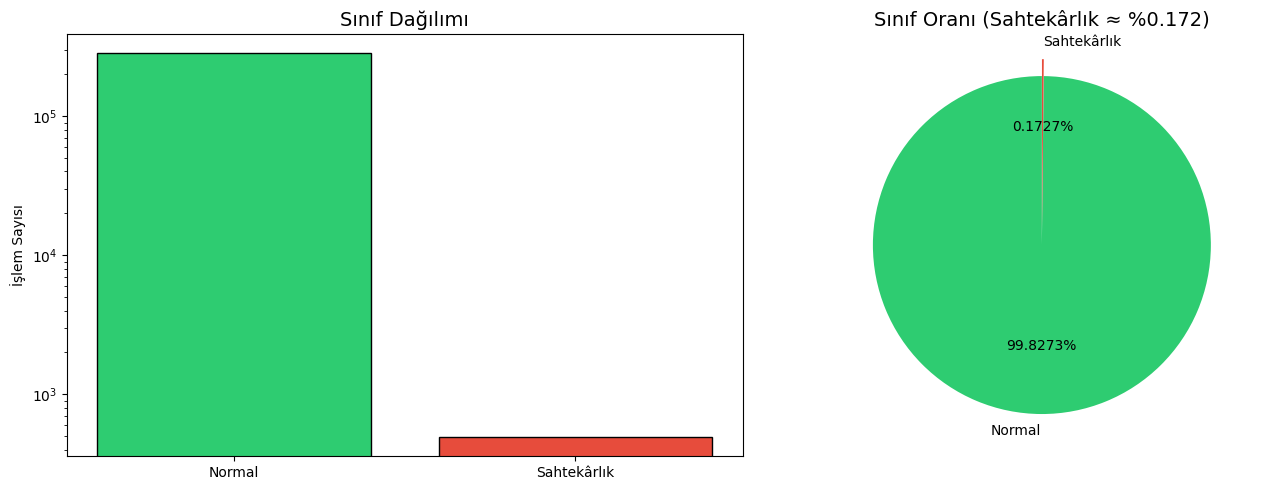


⚠️ Ciddi sınıf dengesizliği var - sahtekârlık çok nadir!


In [5]:
# Sınıf dağılımı grafiği
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['Class'].value_counts()
axes[0].bar(['Normal', 'Sahtekârlık'], class_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Sınıf Dağılımı', fontsize=14)
axes[0].set_ylabel('İşlem Sayısı')
axes[0].set_yscale('log')

axes[1].pie(class_counts.values, labels=['Normal', 'Sahtekârlık'],
            autopct='%1.4f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Sınıf Oranı (Sahtekârlık ≈ %0.172)', fontsize=14)

plt.tight_layout()
plt.show()
print('\n⚠️ Ciddi sınıf dengesizliği var - sahtekârlık çok nadir!')

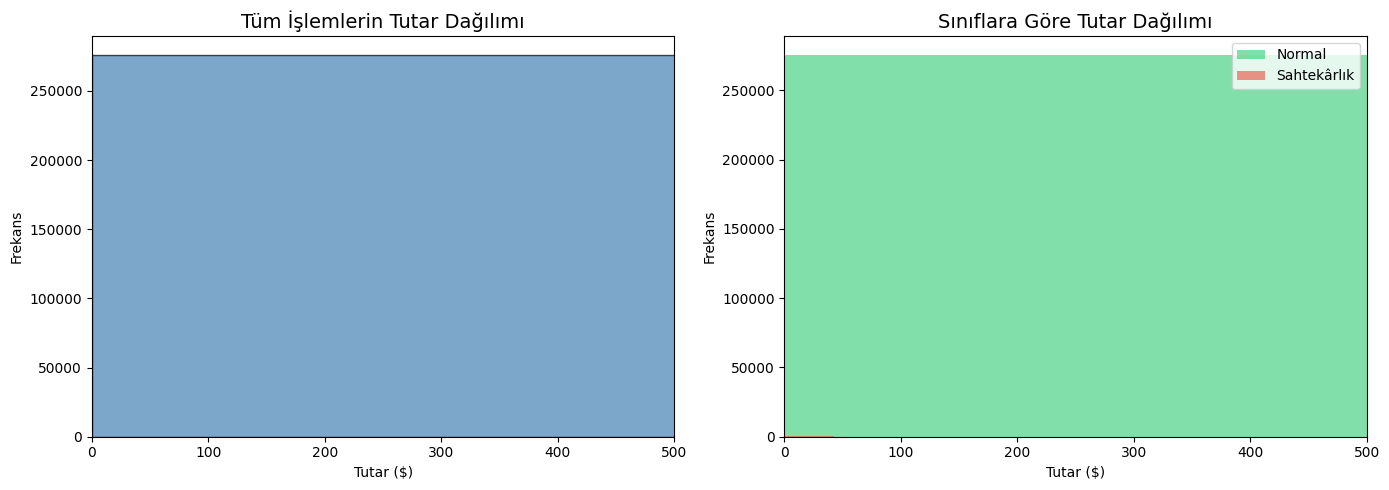

In [6]:
# Transaction Amount (Tutar) dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Amount'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Tüm İşlemlerin Tutar Dağılımı', fontsize=14)
axes[0].set_xlabel('Tutar ($)')
axes[0].set_ylabel('Frekans')
axes[0].set_xlim([0, 500])

axes[1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6,
             label='Normal', color='#2ecc71')
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.6,
             label='Sahtekârlık', color='#e74c3c')
axes[1].set_title('Sınıflara Göre Tutar Dağılımı', fontsize=14)
axes[1].set_xlabel('Tutar ($)')
axes[1].set_ylabel('Frekans')
axes[1].set_xlim([0, 500])
axes[1].legend()

plt.tight_layout()
plt.show()

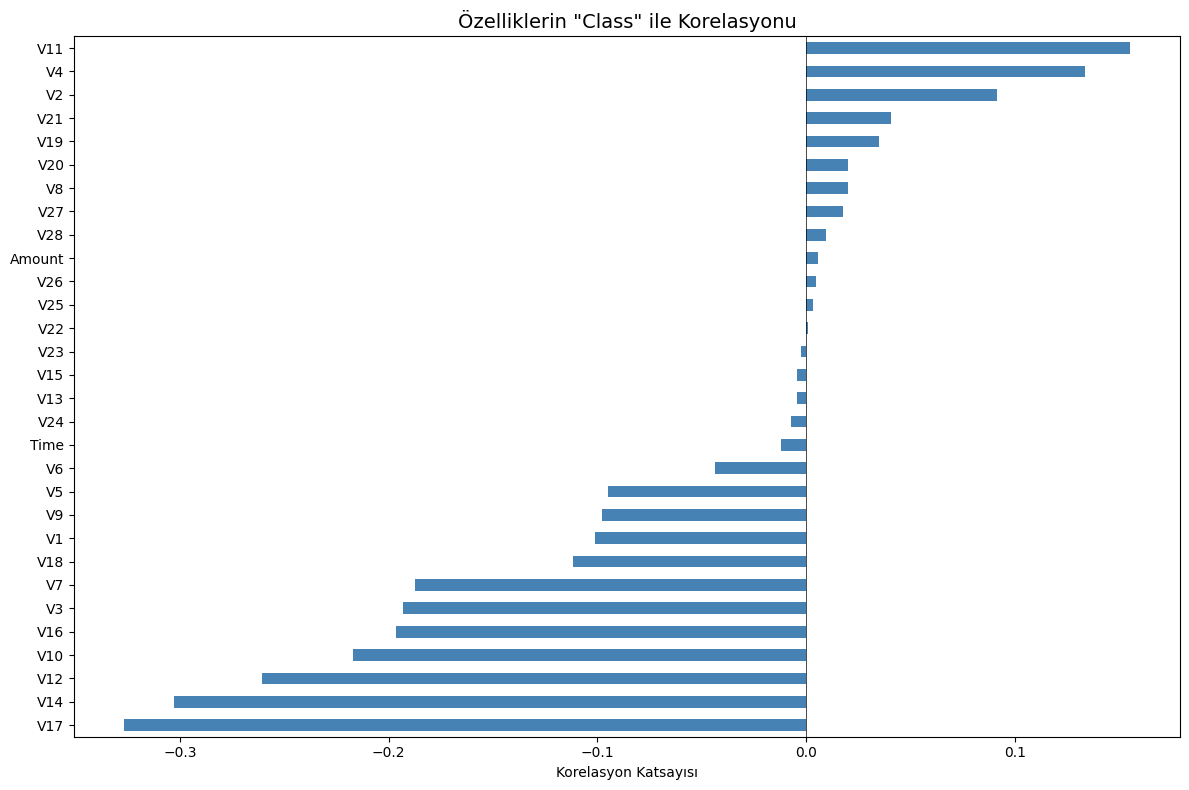

In [7]:
# Korelasyon matrisi
corr_with_class = df.corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
corr_with_class.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Özelliklerin "Class" ile Korelasyonu', fontsize=14)
ax.set_xlabel('Korelasyon Katsayısı')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## 4. Veri Ön İşleme

In [8]:
# Özellikler ve hedef değişkeni ayır
y_true = df['Class'].values
X = df.drop(['Class', 'Time'], axis=1).copy()

# Amount sütununu StandardScaler ile ölçekle
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

print(f'Özellik matrisi boyutu: {X.shape}')
print(f'Hedef değişken boyutu: {y_true.shape}')
print(f'\nSahtekârlık oranı: {y_true.mean()*100:.4f}%')

Özellik matrisi boyutu: (284807, 29)
Hedef değişken boyutu: (284807,)

Sahtekârlık oranı: 0.1727%


## 5. Alt Örneklem Seçimi (Subsampling)

**⚠️ One-Class SVM neden yavaş?**
- One-Class SVM, çekirdek (kernel) hesaplaması yapar
- Bu hesaplama O(n²) karmaşıklığına sahiptir
- 284K veri noktası ile çalışmak çok uzun sürer

**Çözüm:** Rastgele alt örneklem seçerek eğitimi hızlandıracağız.
- Eğitim için ~20,000 normal işlem kullanacağız
- Tüm test verisi ile değerlendirme yapacağız

In [9]:
# Alt örneklem boyutunu belirle
SAMPLE_SIZE = 20000  # Eğitim için kullanılacak örnek sayısı

# Normal işlemleri filtrele
X_normal = X[y_true == 0]
X_fraud = X[y_true == 1]

print(f'Normal işlem sayısı: {len(X_normal):,}')
print(f'Sahtekârlık işlem sayısı: {len(X_fraud):,}')
print()

# Rastgele alt örneklem seç (sadece normal işlemlerden)
np.random.seed(42)
normal_indices = np.random.choice(len(X_normal), size=min(SAMPLE_SIZE, len(X_normal)), replace=False)
X_train = X_normal.iloc[normal_indices]

print(f'Eğitim için seçilen örnek sayısı: {len(X_train):,}')
print(f'Test için kullanılacak veri: {len(X):,} (tüm veri seti)')
print()
print('ℹ️ One-Class SVM sadece normal verilerle eğitilir.')
print('   Anomaliler test sırasında tespit edilir.')

Normal işlem sayısı: 284,315
Sahtekârlık işlem sayısı: 492

Eğitim için seçilen örnek sayısı: 20,000
Test için kullanılacak veri: 284,807 (tüm veri seti)

ℹ️ One-Class SVM sadece normal verilerle eğitilir.
   Anomaliler test sırasında tespit edilir.


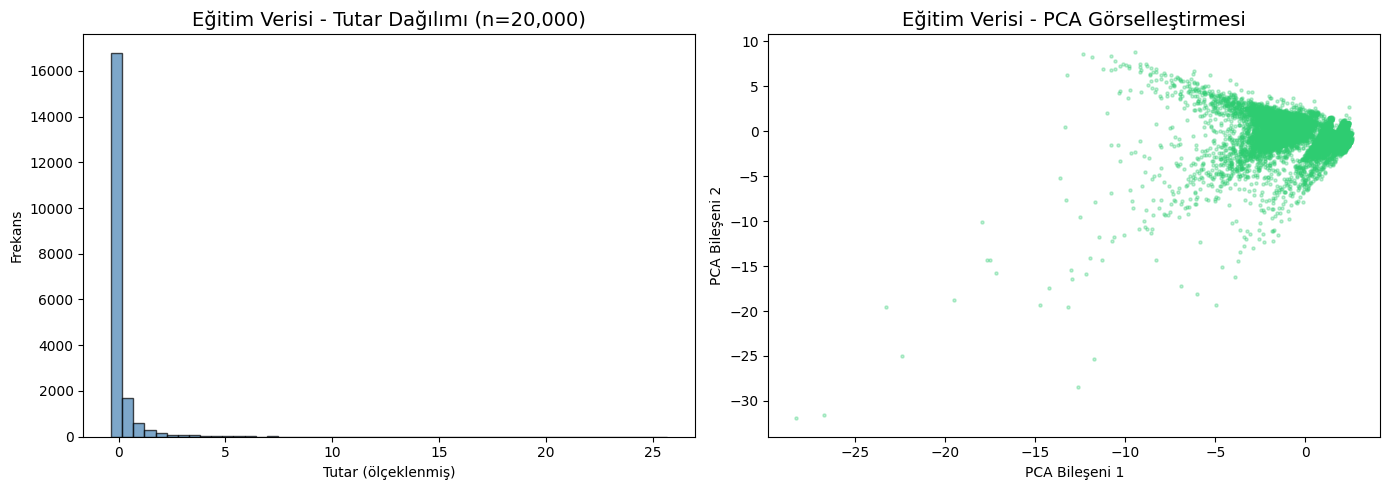

In [10]:
# Eğitim verisinin dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tutar dağılımı
axes[0].hist(X_train['Amount'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Eğitim Verisi - Tutar Dağılımı (n={len(X_train):,})', fontsize=14)
axes[0].set_xlabel('Tutar (ölçeklenmiş)')
axes[0].set_ylabel('Frekans')

# PCA ile 2D görselleştirme
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)

axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
               c='#2ecc71', alpha=0.3, s=5)
axes[1].set_title(f'Eğitim Verisi - PCA Görselleştirmesi', fontsize=14)
axes[1].set_xlabel('PCA Bileşeni 1')
axes[1].set_ylabel('PCA Bileşeni 2')

plt.tight_layout()
plt.show()

## 6. One-Class SVM Modeli Eğitimi

**One-Class SVM:**
- Verileri yüksek boyutlu bir uzaya dönüştürür
- Normal verileri çevreleyen bir "sınırlayıcı" (boundary) oluşturur
- Bu sınırlayıcının dışında kalan noktalar anomali olarak kabul edilir

**Parametreler:**
- `kernel`:çekirdek fonksiyonu (rbf, linear, poly)
- `nu`: Tahmini anomali oranı (0 ile 1 arasında)
- `gamma`: Çekirdek katsayısı (otomatik veya manuel)

In [11]:
# One-Class SVM modelini oluştur ve eğit
print('🔍 One-Class SVM modeli eğitiliyor...')
print(f'   Eğitim verisi boyutu: {len(X_train):,}')
print(f'   Kernel: rbf')
print(f'   nu (tahmini anomali oranı): 0.002')
print(f'   gamma: auto')
print()

# Uyarı: Bu işlem biraz zaman alabilir!
clf = OneClassSVM(
    kernel='rbf',      # Radyal tabanlı fonksiyon çekirdeği
    nu=0.002,          # Tahmini anomali oranı
    gamma='auto',      # Çekirdek katsayısı
    max_iter=10000     # Maksimum iterasyon
)

clf.fit(X_train)
print('✅ One-Class SVM modeli eğitimi tamamlandı!')

🔍 One-Class SVM modeli eğitiliyor...
   Eğitim verisi boyutu: 20,000
   Kernel: rbf
   nu (tahmini anomali oranı): 0.002
   gamma: auto

✅ One-Class SVM modeli eğitimi tamamlandı!


In [12]:
# Tüm veri seti üzerinde tahmin yap
print('🔍 Tüm veri seti üzerinde tahmin yapılıyor...')

y_pred_raw = clf.predict(X)

# sklearn out: 1=normal, -1=anomali → bizim formatımıza çevir
y_pred = (y_pred_raw == -1).astype(int)

# Anomali skorlarını al (negatif değer ne kadar küçükse o kadar anomali)
y_scores = -clf.decision_function(X)

print('📊 Tahmin Sonuçları:')
print(f'   Tahmin edilen anomali sayısı: {sum(y_pred == 1):,}')
print(f'   Gerçek anomali sayısı: {sum(y_true == 1):,}')

🔍 Tüm veri seti üzerinde tahmin yapılıyor...
📊 Tahmin Sonuçları:
   Tahmin edilen anomali sayısı: 8,079
   Gerçek anomali sayısı: 492


In [13]:
# Karışıklık matrisi
cm = confusion_matrix(y_true, y_pred)
print('📋 Karışıklık Matrisi:')
print(f'  True Negatif  (Normal → Normal): {cm[0,0]:,}')
print(f'  False Pozitif (Normal → Anomali): {cm[0,1]:,}')
print(f'  False Negatif (Anomali → Normal): {cm[1,0]:,}')
print(f'  True Pozitif  (Anomali → Anomali): {cm[1,1]:,}')
print()

# Sınıflandırma raporu
print('📋 Sınıflandırma Raporu:')
print('='*60)
print(classification_report(y_true, y_pred,
                            target_names=['Normal', 'Sahtekârlık']))

# ROC-AUC skoru
roc_auc = roc_auc_score(y_true, y_scores)
print(f'\n🎯 ROC-AUC Skoru: {roc_auc:.4f}')

📋 Karışıklık Matrisi:
  True Negatif  (Normal → Normal): 276,655
  False Pozitif (Normal → Anomali): 7,660
  False Negatif (Anomali → Normal): 73
  True Pozitif  (Anomali → Anomali): 419

📋 Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99    284315
 Sahtekârlık       0.05      0.85      0.10       492

    accuracy                           0.97    284807
   macro avg       0.53      0.91      0.54    284807
weighted avg       1.00      0.97      0.98    284807


🎯 ROC-AUC Skoru: 0.9433


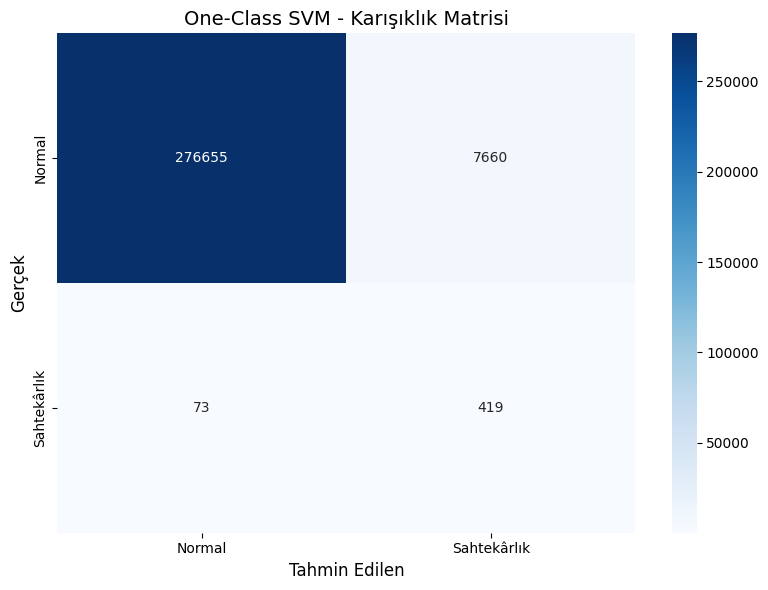

In [14]:
# Karışıklık Matrisi Görselleştirmesi
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Sahtekârlık'],
            yticklabels=['Normal', 'Sahtekârlık'])
ax.set_xlabel('Tahmin Edilen', fontsize=12)
ax.set_ylabel('Gerçek', fontsize=12)
ax.set_title('One-Class SVM - Karışıklık Matrisi', fontsize=14)
plt.tight_layout()
plt.show()

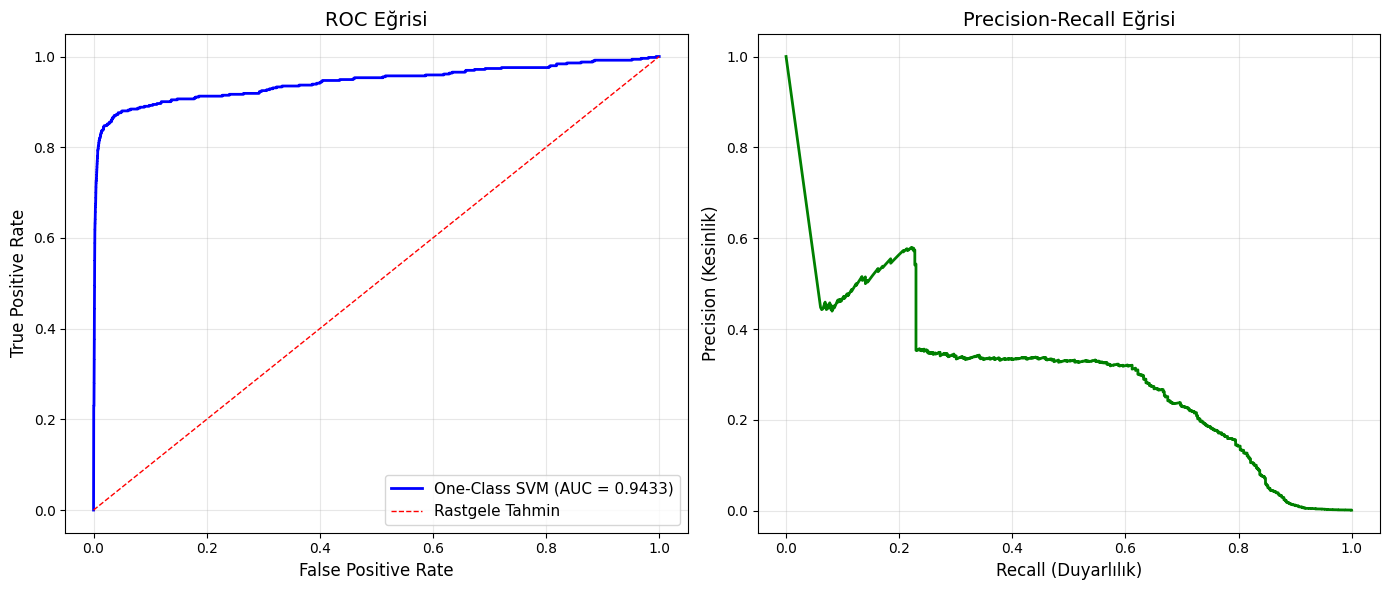

In [15]:
# ROC ve Precision-Recall eğrileri
fpr, tpr, _ = roc_curve(y_true, y_scores)
precision, recall, _ = precision_recall_curve(y_true, y_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC eğrisi
axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'One-Class SVM (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Rastgele Tahmin')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Eğrisi', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Precision-Recall eğrisi
axes[1].plot(recall, precision, 'g-', linewidth=2)
axes[1].set_xlabel('Recall (Duyarlılık)', fontsize=12)
axes[1].set_ylabel('Precision (Kesinlik)', fontsize=12)
axes[1].set_title('Precision-Recall Eğrisi', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

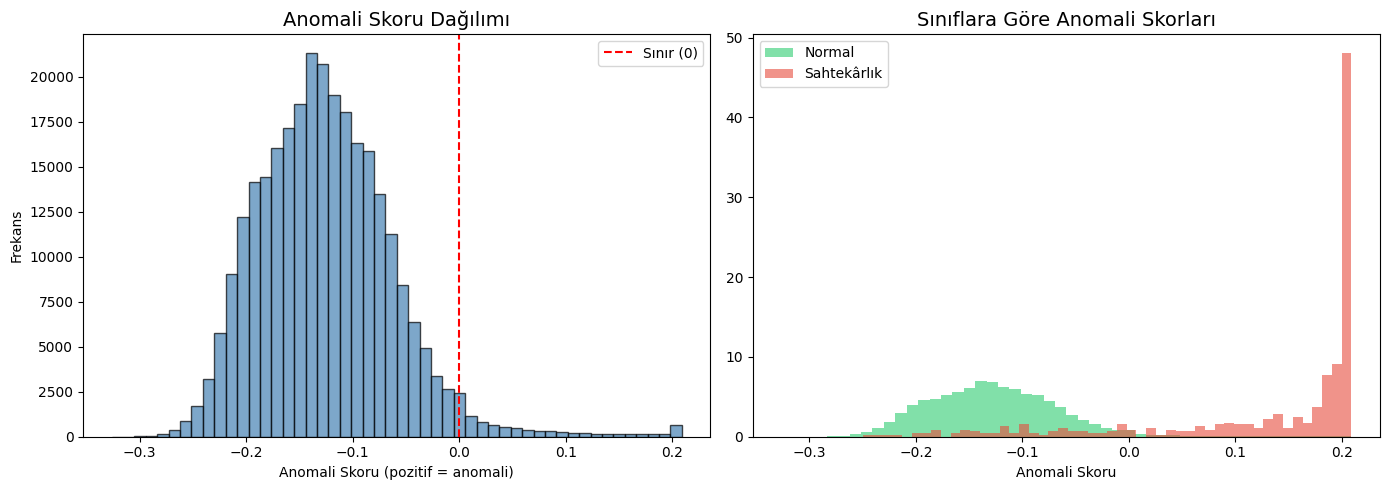

In [16]:
# Anomali skoru dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_scores, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--',
                label='Sınır (0)')
axes[0].set_title('Anomali Skoru Dağılımı', fontsize=14)
axes[0].set_xlabel('Anomali Skoru (pozitif = anomali)')
axes[0].set_ylabel('Frekans')
axes[0].legend()

axes[1].hist(y_scores[y_true==0], bins=50, alpha=0.6,
             label='Normal', color='#2ecc71', density=True)
axes[1].hist(y_scores[y_true==1], bins=50, alpha=0.6,
             label='Sahtekârlık', color='#e74c3c', density=True)
axes[1].set_title('Sınıflara Göre Anomali Skorları', fontsize=14)
axes[1].set_xlabel('Anomali Skoru')
axes[1].legend()

plt.tight_layout()
plt.show()

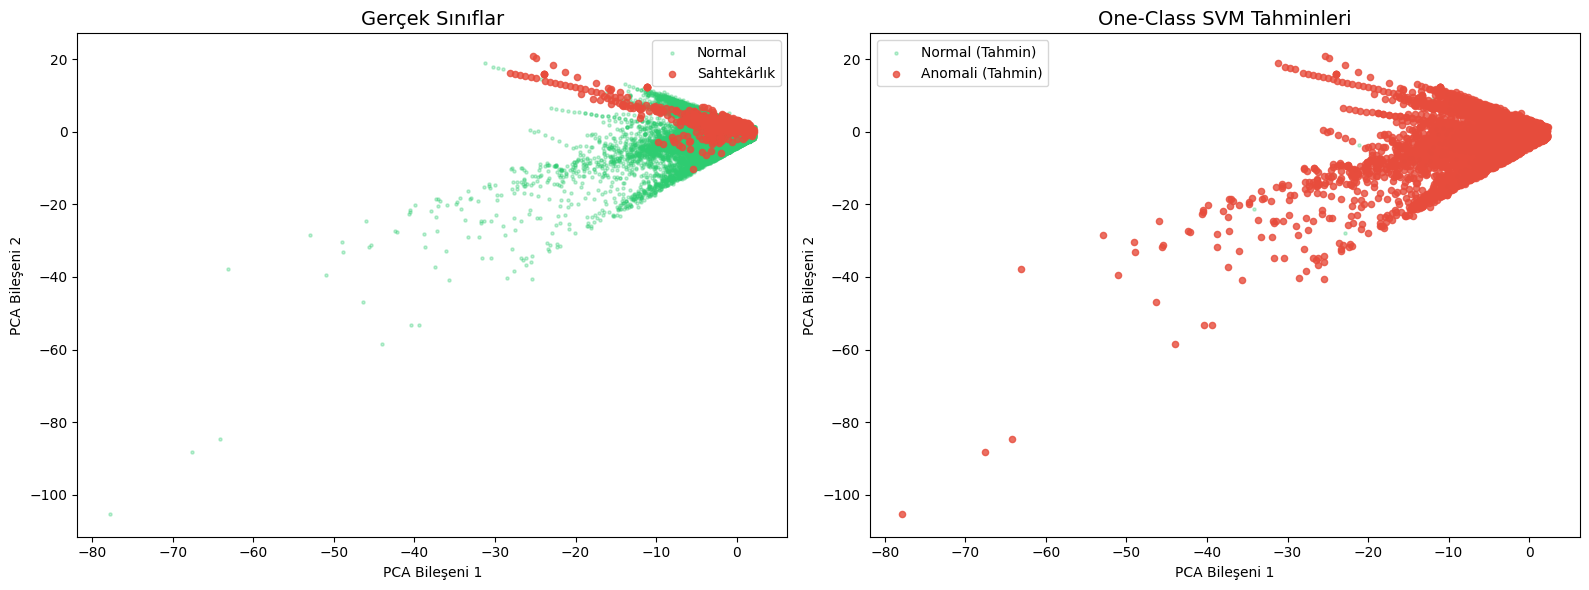

In [17]:
# PCA ile 2D görselleştirme
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gerçek sınıflar
axes[0].scatter(X_pca[y_true==0, 0], X_pca[y_true==0, 1],
               c='#2ecc71', alpha=0.3, s=5, label='Normal')
axes[0].scatter(X_pca[y_true==1, 0], X_pca[y_true==1, 1],
               c='#e74c3c', alpha=0.8, s=20, label='Sahtekârlık')
axes[0].set_title('Gerçek Sınıflar', fontsize=14)
axes[0].set_xlabel('PCA Bileşeni 1')
axes[0].set_ylabel('PCA Bileşeni 2')
axes[0].legend()

# One-Class SVM tahminleri
axes[1].scatter(X_pca[y_pred==0, 0], X_pca[y_pred==0, 1],
               c='#2ecc71', alpha=0.3, s=5, label='Normal (Tahmin)')
axes[1].scatter(X_pca[y_pred==1, 0], X_pca[y_pred==1, 1],
               c='#e74c3c', alpha=0.8, s=20, label='Anomali (Tahmin)')
axes[1].set_title('One-Class SVM Tahminleri', fontsize=14)
axes[1].set_xlabel('PCA Bileşeni 1')
axes[1].set_ylabel('PCA Bileşeni 2')
axes[1].legend()

plt.tight_layout()
plt.show()

📊 Kernel Fonksiyonunun Etkisi (Küçük Alt Örneklemler):

   Kernel: rbf eğitiliyor...
   AUC: 0.9439 | Precision: 0.0262 | Recall: 0.8780

   Kernel: linear eğitiliyor...
   AUC: 0.8292 | Precision: 0.0039 | Recall: 0.7988


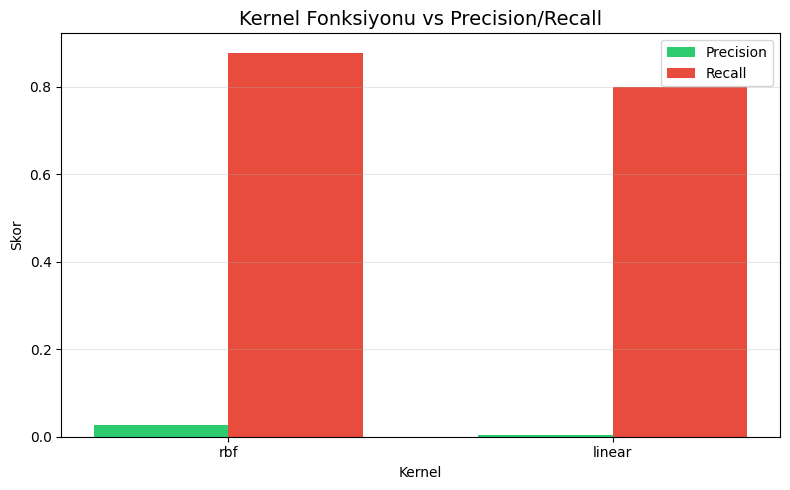

In [18]:
# Kernel fonksiyonunun etkisi
print('📊 Kernel Fonksiyonunun Etkisi (Küçük Alt Örneklemler):')
print('='*60)

# Hızlı deneme için daha küçük örneklem
sample_quick = X_normal.iloc[np.random.choice(len(X_normal), size=5000, replace=False)]

kernel_results = []
kernels = ['rbf', 'linear']

for kernel in kernels:
    print(f'\n   Kernel: {kernel} eğitiliyor...')

    if kernel == 'rbf':
        clf_k = OneClassSVM(kernel=kernel, nu=0.002, gamma='auto', max_iter=10000)
    else:
        clf_k = OneClassSVM(kernel=kernel, nu=0.002)

    clf_k.fit(sample_quick)

    # Tüm veri seti üzerinde test et
    scores_k = -clf_k.decision_function(X)
    pred_k = (clf_k.predict(X) == -1).astype(int)
    auc_k = roc_auc_score(y_true, scores_k)

    tp = np.sum((pred_k == 1) & (y_true == 1))
    fp = np.sum((pred_k == 1) & (y_true == 0))
    fn = np.sum((pred_k == 0) & (y_true == 1))
    precision_k = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_k = tp / (tp + fn) if (tp + fn) > 0 else 0

    kernel_results.append({'Kernel': kernel, 'ROC-AUC': auc_k,
                          'Precision': precision_k, 'Recall': recall_k})
    print(f'   AUC: {auc_k:.4f} | Precision: {precision_k:.4f} | Recall: {recall_k:.4f}')

df_kernel = pd.DataFrame(kernel_results)
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(df_kernel))
width = 0.35

bars1 = ax.bar(x - width/2, df_kernel['Precision'], width, label='Precision', color='#2ecc71')
bars2 = ax.bar(x + width/2, df_kernel['Recall'], width, label='Recall', color='#e74c3c')

ax.set_xlabel('Kernel')
ax.set_ylabel('Skor')
ax.set_title('Kernel Fonksiyonu vs Precision/Recall', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df_kernel['Kernel'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

📊 nu Değerinin Etkisi (Küçük Alt Örneklemler):

   nu=0.001 eğitiliyor...
   AUC: 0.9438 | Precision: 0.0261 | Recall: 0.8780 | Anomali: 16,557

   nu=0.002 eğitiliyor...
   AUC: 0.9439 | Precision: 0.0262 | Recall: 0.8780 | Anomali: 16,493

   nu=0.005 eğitiliyor...
   AUC: 0.9439 | Precision: 0.0261 | Recall: 0.8760 | Anomali: 16,497

   nu=0.01 eğitiliyor...
   AUC: 0.9439 | Precision: 0.0262 | Recall: 0.8760 | Anomali: 16,480


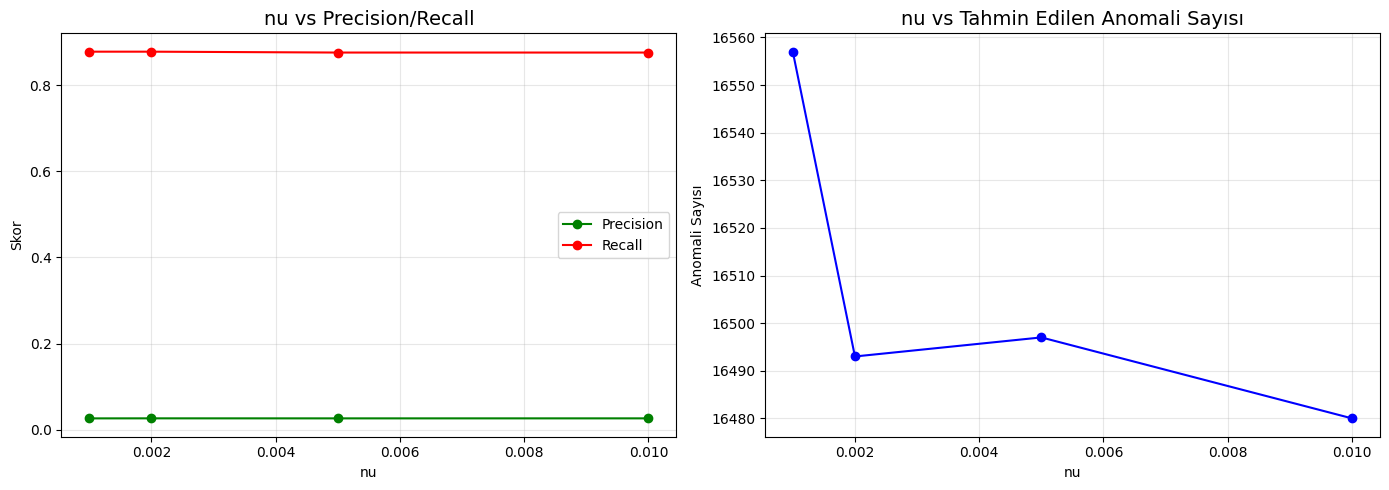

In [19]:
# nu değerinin etkisi
print('📊 nu Değerinin Etkisi (Küçük Alt Örneklemler):')
print('='*60)

nu_values = [0.001, 0.002, 0.005, 0.01]
nu_results = []

for nu in nu_values:
    print(f'\n   nu={nu} eğitiliyor...')
    clf_nu = OneClassSVM(kernel='rbf', nu=nu, gamma='auto', max_iter=10000)
    clf_nu.fit(sample_quick)

    scores_nu = -clf_nu.decision_function(X)
    pred_nu = (clf_nu.predict(X) == -1).astype(int)
    auc_nu = roc_auc_score(y_true, scores_nu)

    tp = np.sum((pred_nu == 1) & (y_true == 1))
    fp = np.sum((pred_nu == 1) & (y_true == 0))
    fn = np.sum((pred_nu == 0) & (y_true == 1))
    precision_nu = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_nu = tp / (tp + fn) if (tp + fn) > 0 else 0

    nu_results.append({'nu': nu, 'ROC-AUC': auc_nu,
                       'Precision': precision_nu, 'Recall': recall_nu,
                       'Tahmin Anomali': sum(pred_nu == 1)})
    print(f'   AUC: {auc_nu:.4f} | Precision: {precision_nu:.4f} | Recall: {recall_nu:.4f} | Anomali: {sum(pred_nu == 1):,}')

df_nu = pd.DataFrame(nu_results)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_nu['nu'], df_nu['Precision'], 'go-', label='Precision')
axes[0].plot(df_nu['nu'], df_nu['Recall'], 'ro-', label='Recall')
axes[0].set_title('nu vs Precision/Recall', fontsize=14)
axes[0].set_xlabel('nu')
axes[0].set_ylabel('Skor')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_nu['nu'], df_nu['Tahmin Anomali'], 'bo-')
axes[1].set_title('nu vs Tahmin Edilen Anomali Sayısı', fontsize=14)
axes[1].set_xlabel('nu')
axes[1].set_ylabel('Anomali Sayısı')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Sonuçlar ve Yorumlama

### One-Class SVM'un Avantajları:
- Çekirdek hilesi (kernel trick) ile doğrusal olmayan sınırlar çizebilir
- Küçük veri setlerinde çok başarılıdır
- Güçlü matematiksel temeli vardır

### One-Class SVM'un Dezavantajları:
- Büyük veri setlerinde çok yavaştır (O(n²))
- Hiperparametre seçimi (kernel, nu, gamma) kritiktir
- Yorumlanması zordur

### Credit Card Fraud Veri Seti İçin Bulgular:
- Alt örneklem ile eğitilmesi gerekiyor (performans için)
- RBF kernel genellikle daha iyi sonuç verir
- nu parametresi anomali oranını doğrudan etkiler
- Diğer yöntemlere göre daha düşük performans gösterebilir

### İyileştirme Önerileri:
1. **Özellik seçimi:** Daha az ama etkili özellikler kullan
2. **Grid search:** Hiperparametreleri sistematik olarak optimize et
3. **Ensemble:** Diğer yöntemlerle birleştirerek daha güçlü bir model oluştur
4. **Nystroem approximation:** Büyük veri setleri için çekirdek yaklaştırması kullan

In [20]:
# En yüksek anomali skorlarına sahip işlemler
df_out = df.copy()
df_out['anomaly_score'] = y_scores
df_out['predicted_anomaly'] = y_pred

# En şüpheli 10 işlem
print('🔍 En Şüpheli 10 İşlem (One-Class SVM):')
print('='*80)
top_suspicious = df_out.nlargest(10, 'anomaly_score')[
    ['Amount', 'Class', 'anomaly_score', 'predicted_anomaly']
]
print(top_suspicious.to_string(index=False))

🔍 En Şüpheli 10 İşlem (One-Class SVM):
 Amount  Class  anomaly_score  predicted_anomaly
7712.43      0       0.208894                  1
  99.99      1       0.208894                  1
  99.99      1       0.208894                  1
  99.99      1       0.208894                  1
  99.99      1       0.208894                  1
   1.00      0       0.208894                  1
  99.99      1       0.208894                  1
  99.99      1       0.208894                  1
  99.99      1       0.208894                  1
  99.99      1       0.208894                  1


📊 Eğitim Veri Boyutunun Etkisi:

   Eğitim boyutu: 1,000 ile deneme...
   AUC: 0.9488 | Precision: 0.0150 | Recall: 0.9024

   Eğitim boyutu: 5,000 ile deneme...
   AUC: 0.9462 | Precision: 0.0282 | Recall: 0.8801

   Eğitim boyutu: 10,000 ile deneme...
   AUC: 0.9418 | Precision: 0.0376 | Recall: 0.8679

   Eğitim boyutu: 20,000 ile deneme...
   AUC: 0.9409 | Precision: 0.0514 | Recall: 0.8476


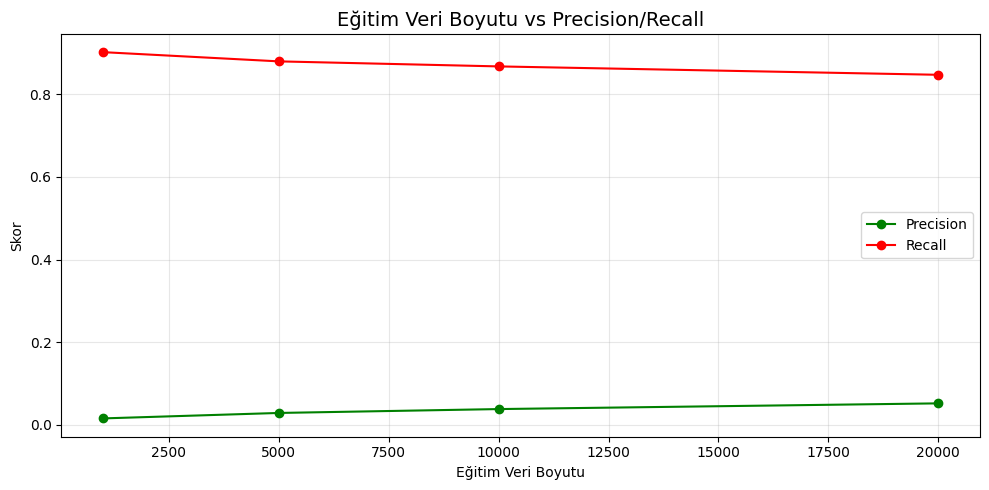

In [21]:
# Eğitim veri boyutunun etkisi
print('📊 Eğitim Veri Boyutunun Etkisi:')
print('='*60)

sample_sizes = [1000, 5000, 10000, 20000]
size_results = []

for size in sample_sizes:
    print(f'\n   Eğitim boyutu: {size:,} ile deneme...')
    sample_s = X_normal.iloc[np.random.choice(len(X_normal), size=min(size, len(X_normal)), replace=False)]

    clf_s = OneClassSVM(kernel='rbf', nu=0.002, gamma='auto', max_iter=10000)
    clf_s.fit(sample_s)

    scores_s = -clf_s.decision_function(X)
    pred_s = (clf_s.predict(X) == -1).astype(int)
    auc_s = roc_auc_score(y_true, scores_s)

    tp = np.sum((pred_s == 1) & (y_true == 1))
    fp = np.sum((pred_s == 1) & (y_true == 0))
    fn = np.sum((pred_s == 0) & (y_true == 1))
    precision_s = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_s = tp / (tp + fn) if (tp + fn) > 0 else 0

    size_results.append({'Eğitim Boyutu': size, 'ROC-AUC': auc_s,
                         'Precision': precision_s, 'Recall': recall_s})
    print(f'   AUC: {auc_s:.4f} | Precision: {precision_s:.4f} | Recall: {recall_s:.4f}')

df_size = pd.DataFrame(size_results)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_size['Eğitim Boyutu'], df_size['Precision'], 'go-', label='Precision')
ax.plot(df_size['Eğitim Boyutu'], df_size['Recall'], 'ro-', label='Recall')
ax.set_title('Eğitim Veri Boyutu vs Precision/Recall', fontsize=14)
ax.set_xlabel('Eğitim Veri Boyutu')
ax.set_ylabel('Skor')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()